# Watchtower Extrinsic Calibration using SIFT Matching

This notebook demonstrates extrinsic camera calibration for the watchtower using SIFT feature matching and PnP algorithm.

The calibration pipeline:
1. Match SIFT features between a reference table image (top-down view) and the camera view
2. Filter matches using RANSAC homography
3. Convert 2D pixel coordinates to 3D world coordinates
4. Solve PnP to estimate camera pose
5. Compare with ground truth (simulation)

The implementation uses the `WatchtowerExtrinsicCalibrator` class from `watchtower_extrinsic_calibration.py`.

In [83]:
# Force external files to be reloaded
import importlib
import sys
from pathlib import Path

# Add parent directory to path
parent_dir = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.insert(0, str(parent_dir))


# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
ros_path = '/opt/ros/jazzy/lib/python3.12/site-packages'
if ros_path not in sys.path:
    sys.path.append(ros_path)
# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tf_transformations as tf_trans

# Reload the module to get latest changes
import champi_watchtower.watchtower_extrinsic_calibration
importlib.reload(champi_watchtower.watchtower_extrinsic_calibration)
from champi_watchtower.watchtower_extrinsic_calibration import WatchtowerExtrinsicCalibrator, compute_calibration_error, compute_axis_alignment_error


In [84]:
# Position/orientation vraie de la caméra (simu)
camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])
camera_support_in_world_quat = np.array([0, 0, -0.707105, 0.707105]) # quaternion (x, y, z, w)
camera_in_support_pos = np.array([0.0, 0.0, 0.91])
camera_in_support_quat = np.array([-0.031363, 0.34146, -0.0859194, 0.935435]) # quaternion (x, y, z, w) 

T_world_support = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_support_in_world_pos),
    tf_trans.quaternion_matrix(camera_support_in_world_quat)
)
T_support_camera = tf_trans.concatenate_matrices(
    tf_trans.translation_matrix(camera_in_support_pos),
    tf_trans.quaternion_matrix(camera_in_support_quat)
)
T_world_camera_true = T_world_support @ T_support_camera
R_true = T_world_camera_true[:3, :3]
t_vector_true = T_world_camera_true[:3, 3]

camera_pos_in_world = tf_trans.translation_from_matrix(T_world_camera_true)
camera_quat_in_world = tf_trans.quaternion_from_matrix(T_world_camera_true)
camera_euler_in_world = tf_trans.euler_from_quaternion(camera_quat_in_world)

print("quat in world (x, y, z, w):", camera_quat_in_world)

quat in world (x, y, z, w): (0.21927176258168785, 0.26362575691152335, -0.7222068562693683, 0.6006984361430138)


In [85]:
camera_matrix = np.array([
    [232.94129521444626, 0.0, 640.0], # k matrix in /camera_info
    [0.0, 232.94129521444626, 400.0],
    [0.0, 0.0, 1.0]
    ])
dist_coeffs = np.array([0, 0, 0, 0, 0]) # d matrix in /camera_info

In [86]:
# Initialize the calibrator
calibrator = WatchtowerExtrinsicCalibrator(
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    table_width=3.0,
    table_height=2.0,
    is_simu_with_webots=True
)

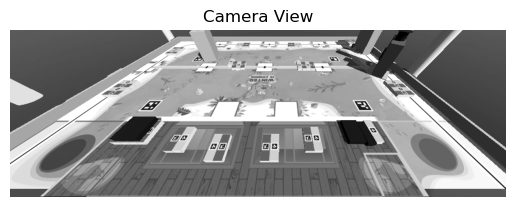

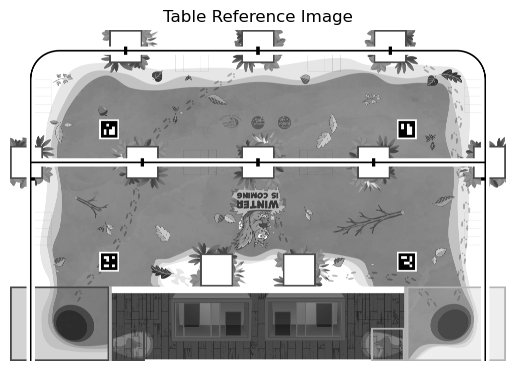

In [112]:
def resolve_image_path(filename: str) -> Path:
    # Support running from notebook dir, package dir, or workspace root.
    roots = []
    if '__file__' in globals():
        roots.append(Path(__file__).resolve().parent)
    roots.append(Path.cwd())

    for root in roots:
        for parent in [root, *root.parents]:
            for rel in (
                Path('ressources/images') / filename,
                Path('champi_vision/ressources/images') / filename,
            ):
                candidate = parent / rel
                if candidate.exists():
                    return candidate

    raise FileNotFoundError(f"Image not found: {filename}")

path_test_img = resolve_image_path('test_img_new_position_watchtower.png')

# Load image
img_camera = cv2.imread(str(path_test_img), 0)  # Grayscale
if img_camera is None:
    raise RuntimeError(f"Failed to load test image: {path_test_img}")

# crop the image to remove the black borders (which can cause issues with SIFT matching)
h, w = img_camera.shape
img_camera = img_camera[270:h-200, 100:w-200]

plt.imshow(img_camera, cmap='gray')
plt.axis('off')
plt.title('Camera View')
plt.show()

path_table_img = resolve_image_path('table_reference_2026.png')
img_tapis = cv2.imread(str(path_table_img), 0)  # Grayscale
if img_tapis is None:
    raise RuntimeError(f"Failed to load table image: {path_table_img}")

img_tapis = cv2.rotate(img_tapis, cv2.ROTATE_180)
plt.imshow(img_tapis, cmap='gray')
plt.axis('off')
plt.title('Table Reference Image')
plt.show()

In [119]:
# Perform calibration using the library
result = calibrator.calibrate(img_tapis, img_camera)

if result['success']:
    print(f"✓ Calibration successful!")
    print(f"  Number of inliers: {result['num_inliers']}")
    print(f"  Reprojection error: {result['reprojection_error']:.4f} pixels")
else:
    print(f"✗ Calibration failed: {result['error']}")

✓ Calibration successful!
  Number of inliers: 539
  Reprojection error: 1.2188 pixels


In [125]:
# Compare with ground truth
if result['success']:
    M_T_camera_to_world = result['M_T_camera_to_world']
    
    # Ground truth camera pose
    pos_true = camera_pos_in_world
    quat_true = camera_quat_in_world

    pos_est = M_T_camera_to_world[:3, 3]
    R_est = M_T_camera_to_world[:3, :3]
    quat_est = tf_trans.quaternion_from_matrix(M_T_camera_to_world)
    
    # Compute errors
    dist_error, angle_error_quat = compute_calibration_error(M_T_estimated=M_T_camera_to_world, M_T_true=T_world_camera_true)
    
    # Compute per-axis alignment errors
    angle_error_x = compute_axis_alignment_error(R_est, R_true, np.array([1, 0, 0]))
    angle_error_y = compute_axis_alignment_error(R_est, R_true, np.array([0, 1, 0]))
    angle_error_z = compute_axis_alignment_error(R_est, R_true, np.array([0, 0, 1]))
    
    print("=== CALIBRATION RESULTS ===")
    print(f"Position (True)     : {pos_true}")
    print(f"Position (Estimated): {pos_est}")
    print(f"")
    print(f"Quaternion (True)      : {quat_true}")
    print(f"Quaternion (Estimated) : {quat_est}")
    print(f"")
    print("=== ERRORS ===")
    print(f"Position error    : {dist_error * 100:.2f} cm")
    print(f"Orientation error : {angle_error_quat:.4f}°")
    print(f"")
    print("=== PER-AXIS ALIGNMENT ERRORS ===")
    print(f"X-axis error : {angle_error_x:.4f}°")
    print(f"Y-axis error : {angle_error_y:.4f}°")
    print(f"Z-axis error : {angle_error_z:.4f}°")
    print(f"")
    print(f"Reprojection error: {result['reprojection_error']:.4f} pixels")


# IN SIMU results are:
# Position error    : 0.07 cm
# Orientation error : 0.0387°

=== CALIBRATION RESULTS ===
Position (True)     : [-0.225  1.12   0.99 ]
Position (Estimated): [ 282.56653237 -122.274475     34.48598638]

Quaternion (True)      : (0.21927176258168785, 0.26362575691152335, -0.7222068562693683, 0.6006984361430138)
Quaternion (Estimated) : (0.1039544910279391, -0.9416231344326452, -0.2495773810696686, 0.20062519122674488)

=== ERRORS ===
Position error    : 31035.34 cm
Orientation error : 171.3608°

=== PER-AXIS ALIGNMENT ERRORS ===
X-axis error : 79.6511°
Y-axis error : 105.8452°
Z-axis error : 152.1177°

Reprojection error: 1.2188 pixels


In [120]:
# Re-run feature matching to get visualization data
inlier_src, inlier_dst, num_inliers = calibrator.detect_and_match_features(img_tapis, img_camera)

# For visualization, we need to recreate the SIFT keypoints and matches
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img_tapis, None)
kp2, des2 = sift.detectAndCompute(img_camera, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < calibrator.sift_ratio_threshold * n.distance:
        good_matches.append(m)

# Get homography to identify inliers
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
_, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, calibrator.ransac_threshold)

matches_mask = mask.ravel().tolist()


draw_params = dict(matchColor=(0, 255, 0),  # Green lines for inliers
                singlePointColor=None,
                matchesMask=matches_mask,
                flags=3)

img_matches = cv2.drawMatches(img_tapis, kp1, img_camera, kp2, good_matches, None, **draw_params)

plt.figure(figsize=(18, 9))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"RANSAC Inliers: {num_inliers} matched features (Table vs Camera)")
plt.axis('off')
plt.show()

error: OpenCV(4.11.0) /io/opencv/modules/features2d/src/draw.cpp:156: error: (-201:Incorrect size of input array) outImg has size less than need to draw img1 and img2 together in function '_prepareImgAndDrawKeypoints'
